# Assignment: Matrix Multiplication Performance with Cython

**Course:** EE2703 - Applied Programming Laboratory  
**Topic:** Introduction to Cython for Performance Optimization

---

## Learning Objectives

In this assignment, you will:
1. Profile pure Python matrix multiplication code
2. Progressively optimize it using Cython techniques
3. Compare performance against NumPy's optimized implementation
4. Understand when and why to use Cython

## Instructions

1. **Complete all sections** marked with `# YOUR CODE HERE`
2. **Run all cells in order** - Use "Restart & Run All" before submission
3. **Fill in the analysis sections** with your observations
4. **Submit this notebook** with all outputs visible

---

## Setup

If you are running this on the JupyterLab server https://jup.dev.iitm.ac.in/ all the required modules are already present and you should not need anything new installed.  The final code will be evaluated on this machine, so in case you use any modules not present there your code may not work.  You can temporarily work on a Google colab notebook if you find that comfortable, but keep in mind that final evaluation will be on the Jup server.

If you are running it on your own system, you *may* need to install the following packages:

```bash
pip install setuptools cython numpy pandas matplotlib jupyter
```

The template code has been written assuming you will use a notebook that supports the `%%cython` magic commands.  Hence, a plain Python script will **NOT** be acceptable.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Cython magic
%load_ext cython

print("Setup complete!")

Setup complete!


## Part 1: Baseline Python Implementation

Implement a simple matrix multiplication function in pure Python using nested loops. This should be similar to what you did in your first assignment.

**Requirements:**
- Use three nested loops (i, j, k)
- No NumPy or other libraries
- Handle matrices as lists of lists

In [2]:
def matmul_python(A, B):
    """
    Pure Python matrix multiplication.
    
    Args:
        A: Matrix of size (m, n) as list of lists
        B: Matrix of size (n, p) as list of lists
    
    Returns:
        Result matrix of size (m, p) as list of lists
    """
    # --- Validation of inputs ---
    
    # 1. Check if both inputs are lists (nested lists)
    if not isinstance(A, list) or not isinstance(B, list):
        raise ValueError("Both inputs must be nested lists representing matrices.")

    # 2. Check for empty matrices
    if not A or not B:
        raise ValueError("Input matrices must not be empty.")

    # 3. Validate A rows (must all be lists of equal length)
    m = len(A)  # rows in A
    N1 = None
    for row in A:
        if not isinstance(row, list):
            raise ValueError("Each row of A must be a list.")
        if N1 is None:
            N1 = len(row)  # set number of columns for A
        elif len(row) != N1:
            raise ValueError("All rows in A must have the same number of columns.")

    # 4. Validate B rows (must all be lists of equal length)
    N2 = len(B)  # rows in B
    p = None
    for row in B:
        if not isinstance(row, list):
            raise ValueError("Each row of B must be a list.")
        if p is None:
            p = len(row)  # set number of columns for B
        elif len(row) != p:
            raise ValueError("All rows in B must have the same number of columns.")

    # 5. Check matrix dimensions (N1 == N2 required for multiplication)
    if N1 != N2:
        raise ValueError("Incompatible dimensions: "
                         f"A has {N1} columns, B has {N2} rows.")
    else:
        n = N1
    # --- Matrix multiplication ---
    
    result = []
    for i in range(m):  # for each row in A
        row_result = []
        for j in range(p):  # for each column in B
            product_sum = 0
            for k in range(n):  # dot product of row i (A) and col j (B)
                a, b = A[i][k], B[k][j]
                if not isinstance(a, (int, float)) or not isinstance(b, (int, float)):
                    raise TypeError("Matrix entries must be numeric (int or float).")
                product_sum += a * b
            row_result.append(product_sum)
        result.append(row_result)

    return result



### Test the Implementation

In [ ]:
# Small test to verify correctness
A_test = [[1, 2], [3, 4]]
B_test = [[5, 6], [7, 8]]
C_test = matmul_python(A_test, B_test)

print("Test multiplication:")
print(f"A = {A_test}")
print(f"B = {B_test}")
print(f"C = {C_test}")
print(f"\nExpected: [[19, 22], [43, 50]]")

# Verify with NumPy
A_np = np.array(A_test)
B_np = np.array(B_test)
C_np = A_np @ B_np
print(f"NumPy result: {C_np.tolist()}")

Test multiplication:
A = [[1, 2], [3, 4]]
B = [[5, 6], [7, 8]]
C = [[19, 22], [43, 50]]

Expected: [[19, 22], [43, 50]]
NumPy result: [[19, 22], [43, 50]]


### Timing Function

We'll use this helper function to time all implementations.

In [4]:
def time_matmul(func, A, B, name="", runs=3):
    """
    Time a matrix multiplication function.
    
    Args:
        func: Function to time
        A, B: Input matrices
        name: Name for display
        runs: Number of runs to average
    
    Returns:
        Average time in seconds
    """
    times = []
    for _ in range(runs):
        start = time.time()
        result = func(A, B)
        elapsed = time.time() - start
        times.append(elapsed)
    
    avg_time = sum(times) / len(times)
    print(f"{name:30s}: {avg_time:.4f} seconds")
    return avg_time

### Benchmark Python Implementation

Test with different matrix sizes.

In [5]:
# Create test matrices of different sizes
sizes = [64, 128, 256, 512]
python_times = []

print("Benchmarking Pure Python Implementation")
print("=" * 50)

for size in sizes:
    # Create random matrices as lists
    A = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    B = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    
    print(f"\nSize {size}x{size}:")
    t = time_matmul(matmul_python, A, B, f"Python {size}x{size}")
    python_times.append(t)

Benchmarking Pure Python Implementation

Size 64x64:
Python 64x64                  : 0.0643 seconds

Size 128x128:
Python 128x128                : 0.5289 seconds

Size 256x256:
Python 256x256                : 5.1666 seconds

Size 512x512:
Python 512x512                : 40.0559 seconds


---

## Part 2: Cython Level 1 - Basic Compilation

In this level, we simply compile the Python code with Cython without any modifications. This gives us a baseline for Cython's improvement.

**Task:** Copy your Python function into the Cython cell below (with `%%cython` magic).

In [6]:
%%cython

def matmul_cython_level1(A, B):
    """
    Level 1: Pure Python code compiled with Cython.
    No optimizations, just basic compilation.
    """
    # YOUR CODE HERE - Copy your Python implementation
    # --- Validation of inputs ---
    
    # 1. Check if both inputs are lists (nested lists)
    if not isinstance(A, list) or not isinstance(B, list):
        raise ValueError("Both inputs must be nested lists representing matrices.")

    # 2. Check for empty matrices
    if not A or not B:
        raise ValueError("Input matrices must not be empty.")

    # 3. Validate A rows (must all be lists of equal length)
    m = len(A)  # rows in A
    N1 = None
    for row in A:
        if not isinstance(row, list):
            raise ValueError("Each row of A must be a list.")
        if N1 is None:
            N1 = len(row)  # set number of columns for A
        elif len(row) != N1:
            raise ValueError("All rows in A must have the same number of columns.")

    # 4. Validate B rows (must all be lists of equal length)
    N2 = len(B)  # rows in B
    p = None
    for row in B:
        if not isinstance(row, list):
            raise ValueError("Each row of B must be a list.")
        if p is None:
            p = len(row)  # set number of columns for B
        elif len(row) != p:
            raise ValueError("All rows in B must have the same number of columns.")

    # 5. Check matrix dimensions (N1 == N2 required for multiplication)
    if N1 != N2:
        raise ValueError("Incompatible dimensions: "
                         f"A has {N1} columns, B has {N2} rows.")
    else:
        n = N1
    # --- Matrix multiplication ---
    
    result = []
    for i in range(m):  # for each row in A
        row_result = []
        for j in range(p):  # for each column in B
            product_sum = 0
            for k in range(n):  # dot product of row i (A) and col j (B)
                a, b = A[i][k], B[k][j]
                if not isinstance(a, (int, float)) or not isinstance(b, (int, float)):
                    raise TypeError("Matrix entries must be numeric (int or float).")
                product_sum += a * b
            row_result.append(product_sum)
        result.append(row_result)

    return result


### Benchmark Level 1

In [7]:
cython_level1_times = []

print("Benchmarking Cython Level 1 (Basic Compilation)")
print("=" * 50)

for size in sizes:
    A = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    B = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    
    print(f"\nSize {size}x{size}:")
    t = time_matmul(matmul_cython_level1, A, B, f"Cython L1 {size}x{size}")
    cython_level1_times.append(t)
    
    speedup = python_times[sizes.index(size)] / t
    print(f"  Speedup vs Python: {speedup:.2f}x")

Benchmarking Cython Level 1 (Basic Compilation)

Size 64x64:
Cython L1 64x64               : 0.0227 seconds
  Speedup vs Python: 2.83x

Size 128x128:
Cython L1 128x128             : 0.1866 seconds
  Speedup vs Python: 2.83x

Size 256x256:
Cython L1 256x256             : 1.7231 seconds
  Speedup vs Python: 3.00x

Size 512x512:
Cython L1 512x512             : 20.4166 seconds
  Speedup vs Python: 1.96x


---

## Part 3: Cython Level 2 - Type Declarations

Now we add static type declarations to help Cython generate efficient C code.

**Key optimizations:**
- Use `cdef` to declare loop variables as integers
- Declare matrix dimensions as integers
- Use `cdef` for the accumulator variable

**Task:** Add type declarations to your code.

In [8]:
%%cython

def matmul_cython_level2(A, B):
    """
    Level 2: Add static type declarations.
    This allows Cython to generate more efficient C code.
    """
    cdef int m, n, p, N1, N2
    cdef int i, j, k
    cdef double product_sum
    # --- Validation of inputs ---
    
    # 1. Check if both inputs are lists (nested lists)
    if not isinstance(A, list) or not isinstance(B, list):
        raise ValueError("Both inputs must be nested lists representing matrices.")

    # 2. Check for empty matrices
    if not A or not B:
        raise ValueError("Input matrices must not be empty.")

    # 3. Validate A rows (must all be lists of equal length)
    m = len(A)  # rows in A
    N1 = -1 # Changed from None to -1
    for row in A:
        if not isinstance(row, list):
            raise ValueError("Each row of A must be a list.")
        if N1 == -1:
            N1 = len(row)  # set number of columns for A
        elif len(row) != N1:
            raise ValueError("All rows in A must have the same number of columns.")

    # 4. Validate B rows (must all be lists of equal length)
    N2 = len(B)  # rows in B
    p = -1 # Changed from None to -1
    for row in B:
        if not isinstance(row, list):
            raise ValueError("Each row of B must be a list.")
        if p == -1:
            p = len(row)  # set number of columns for B
        elif len(row) != p:
            raise ValueError("All rows in B must have the same number of columns.")

    # 5. Check matrix dimensions (N1 == N2 required for multiplication)
    if N1 != N2:
        raise ValueError("Incompatible dimensions: "
                         f"A has {N1} columns, B has {N2} rows.")
    else:
        n = N1
    # --- Matrix multiplication ---
    
    result = []
    for i in range(m):  # for each row in A
        row_result = []
        for j in range(p):  # for each column in B
            product_sum = 0
            for k in range(n):  # dot product of row i (A) and col j (B)
                a, b = A[i][k], B[k][j]
                if not isinstance(a, (int, float)) or not isinstance(b, (int, float)):
                    raise TypeError("Matrix entries must be numeric (int or float).")
                product_sum += a * b
            row_result.append(product_sum)
        result.append(row_result)

    return result


### Benchmark Level 2

In [9]:
cython_level2_times = []

print("Benchmarking Cython Level 2 (Type Declarations)")
print("=" * 50)

for size in sizes:
    A = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    B = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    
    print(f"\nSize {size}x{size}:")
    t = time_matmul(matmul_cython_level2, A, B, f"Cython L2 {size}x{size}")
    cython_level2_times.append(t)
    
    speedup = python_times[sizes.index(size)] / t
    print(f"  Speedup vs Python: {speedup:.2f}x")
    print(f"  Speedup vs Level 1: {cython_level1_times[sizes.index(size)] / t:.2f}x")

Benchmarking Cython Level 2 (Type Declarations)

Size 64x64:
Cython L2 64x64               : 0.0181 seconds
  Speedup vs Python: 3.55x
  Speedup vs Level 1: 1.25x

Size 128x128:
Cython L2 128x128             : 0.1389 seconds
  Speedup vs Python: 3.81x
  Speedup vs Level 1: 1.34x

Size 256x256:
Cython L2 256x256             : 1.1091 seconds
  Speedup vs Python: 4.66x
  Speedup vs Level 1: 1.55x

Size 512x512:
Cython L2 512x512             : 18.6942 seconds
  Speedup vs Python: 2.14x
  Speedup vs Level 1: 1.09x


---

## Part 4: Cython Level 3 - NumPy Arrays with Memory Views

The biggest speedup comes from using NumPy arrays with Cython's memory views. This allows direct access to array data without Python overhead.

**Key optimizations:**
- Accept NumPy arrays as input (not lists)
- Use memory view syntax: `double[:, :]` for 2D arrays
- Add compiler directives to disable safety checks - `boundscheck` and `wraparound` are useful decorators

**Task:** Implement the fully optimized version using memory views.

In [10]:
%%cython
import numpy as np
cimport numpy as np
cimport cython


@cython.boundscheck(False)
@cython.wraparound(False)
def matmul_cython_level3(double[:, :] A, double[:, :] B):
    """
    Level 3: Use NumPy arrays with memory views for maximum speed.
    This provides direct access to array data without Python overhead.
    """
    cdef int m, n, p, N1, N2
    cdef int i, j, k
    cdef float product_sum

    m = A.shape[0]  # rows in A
    N1 = A.shape[1] 
    N2 = B.shape[0]  # rows in B
    p = B.shape[1] 
    # 5. Check matrix dimensions (N1 == N2 required for multiplication)
    if N1 != N2:
        raise ValueError("Incompatible dimensions: "
                         f"A has {N1} columns, B has {N2} rows.")
    else:
        n = N1
    
    cdef double[:, :] result = np.zeros((m, p), dtype=np.float64)
    for i in range(m):  # for each row in A
        for j in range(p):  # for each column in B
            result[i,j] = 0
            for k in range(n):  # dot product of row i (A) and col j (B)
                
                result[i,j] += A[i,k] * B[k,j]

    return result


### Benchmark Level 3

In [11]:
cython_level3_times = []

print("Benchmarking Cython Level 3 (Memory Views)")
print("=" * 50)

for size in sizes:
    # Create NumPy arrays for this version
    A_np = np.random.rand(size, size)
    B_np = np.random.rand(size, size)
    
    print(f"\nSize {size}x{size}:")
    t = time_matmul(matmul_cython_level3, A_np, B_np, f"Cython L3 {size}x{size}")
    cython_level3_times.append(t)
    
    speedup = python_times[sizes.index(size)] / t
    print(f"  Speedup vs Python: {speedup:.2f}x")
    print(f"  Speedup vs Level 2: {cython_level2_times[sizes.index(size)] / t:.2f}x")

Benchmarking Cython Level 3 (Memory Views)

Size 64x64:
Cython L3 64x64               : 0.0007 seconds
  Speedup vs Python: 96.50x
  Speedup vs Level 2: 27.17x

Size 128x128:
Cython L3 128x128             : 0.0043 seconds
  Speedup vs Python: 121.95x
  Speedup vs Level 2: 32.02x

Size 256x256:
Cython L3 256x256             : 0.0232 seconds
  Speedup vs Python: 223.00x
  Speedup vs Level 2: 47.87x

Size 512x512:
Cython L3 512x512             : 0.6477 seconds
  Speedup vs Python: 61.84x
  Speedup vs Level 2: 28.86x


---

## Part 5: NumPy Comparison

Compare all your implementations with NumPy's highly optimized matrix multiplication.

NumPy uses BLAS (Basic Linear Algebra Subprograms), which are highly optimized, often in assembly language, and may use SIMD instructions.

In [12]:
def matmul_numpy(A, B):
    """NumPy matrix multiplication using @ operator."""
    return A @ B

numpy_times = []

print("Benchmarking NumPy Implementation")
print("=" * 50)

for size in sizes:
    A_np = np.random.rand(size, size)
    B_np = np.random.rand(size, size)
    
    print(f"\nSize {size}x{size}:")
    t = time_matmul(matmul_numpy, A_np, B_np, f"NumPy {size}x{size}")
    numpy_times.append(t)
    
    speedup = python_times[sizes.index(size)] / t
    print(f"  Speedup vs Python: {speedup:.2f}x")

Benchmarking NumPy Implementation

Size 64x64:
NumPy 64x64                   : 0.0078 seconds
  Speedup vs Python: 8.22x

Size 128x128:
NumPy 128x128                 : 0.0017 seconds
  Speedup vs Python: 317.05x

Size 256x256:
NumPy 256x256                 : 0.0037 seconds
  Speedup vs Python: 1410.04x

Size 512x512:
NumPy 512x512                 : 0.0119 seconds
  Speedup vs Python: 3379.17x


---

## Part 6: Analysis and Reflection

### Summary Table

Create a comprehensive comparison table.

In [13]:
# Create summary DataFrame
results = {
    'Size': [f"{s}x{s}" for s in sizes],
    'Python (s)': python_times,
    'Cython L1 (s)': cython_level1_times,
    'Cython L2 (s)': cython_level2_times,
    'Cython L3 (s)': cython_level3_times,
    'NumPy (s)': numpy_times,
}

df = pd.DataFrame(results)

# Add speedup columns
df['Speedup L1'] = df['Python (s)'] / df['Cython L1 (s)']
df['Speedup L2'] = df['Python (s)'] / df['Cython L2 (s)']
df['Speedup L3'] = df['Python (s)'] / df['Cython L3 (s)']
df['Speedup NumPy'] = df['Python (s)'] / df['NumPy (s)']

print("\n" + "=" * 80)
print("TIMING RESULTS (seconds)")
print("=" * 80)
print(df[['Size', 'Python (s)', 'Cython L1 (s)', 'Cython L2 (s)', 'Cython L3 (s)', 'NumPy (s)']].to_string(index=False))

print("\n" + "=" * 80)
print("SPEEDUP FACTORS (vs Pure Python)")
print("=" * 80)
print(df[['Size', 'Speedup L1', 'Speedup L2', 'Speedup L3', 'Speedup NumPy']].to_string(index=False))


TIMING RESULTS (seconds)
   Size  Python (s)  Cython L1 (s)  Cython L2 (s)  Cython L3 (s)  NumPy (s)
  64x64    0.064313       0.022705       0.018107       0.000666   0.007822
128x128    0.528925       0.186602       0.138872       0.004337   0.001668
256x256    5.166642       1.723112       1.109071       0.023168   0.003664
512x512   40.055944      20.416556      18.694207       0.647709   0.011854

SPEEDUP FACTORS (vs Pure Python)
   Size  Speedup L1  Speedup L2  Speedup L3  Speedup NumPy
  64x64    2.832488    3.551708   96.498808       8.222052
128x128    2.834510    3.808719  121.952138     317.045351
256x256    2.998436    4.658529  223.003012    1410.042055
512x512    1.961934    2.142693   61.842526    3379.172156


### Visualization

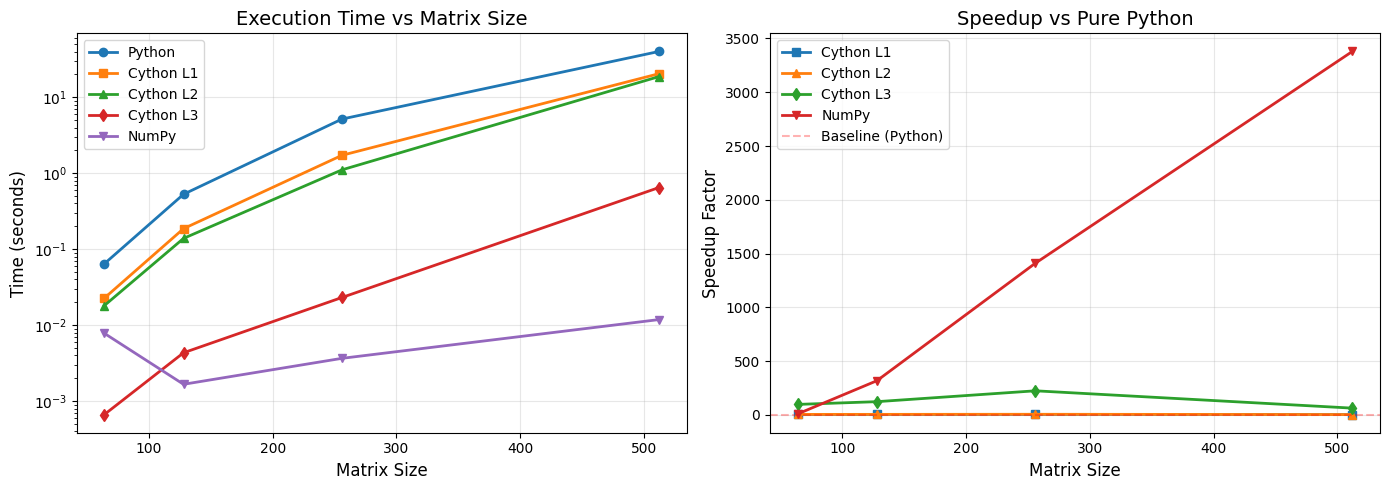

Figure saved as 'matmul_performance.png'


In [14]:
# Plot timing comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Absolute timing
ax1.plot(sizes, python_times, 'o-', label='Python', linewidth=2)
ax1.plot(sizes, cython_level1_times, 's-', label='Cython L1', linewidth=2)
ax1.plot(sizes, cython_level2_times, '^-', label='Cython L2', linewidth=2)
ax1.plot(sizes, cython_level3_times, 'd-', label='Cython L3', linewidth=2)
ax1.plot(sizes, numpy_times, 'v-', label='NumPy', linewidth=2)
ax1.set_xlabel('Matrix Size', fontsize=12)
ax1.set_ylabel('Time (seconds)', fontsize=12)
ax1.set_title('Execution Time vs Matrix Size', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Speedup comparison
ax2.plot(sizes, df['Speedup L1'], 's-', label='Cython L1', linewidth=2)
ax2.plot(sizes, df['Speedup L2'], '^-', label='Cython L2', linewidth=2)
ax2.plot(sizes, df['Speedup L3'], 'd-', label='Cython L3', linewidth=2)
ax2.plot(sizes, df['Speedup NumPy'], 'v-', label='NumPy', linewidth=2)
ax2.axhline(y=1, color='r', linestyle='--', alpha=0.3, label='Baseline (Python)')
ax2.set_xlabel('Matrix Size', fontsize=12)
ax2.set_ylabel('Speedup Factor', fontsize=12)
ax2.set_title('Speedup vs Pure Python', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('matmul_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved as 'matmul_performance.png'")

### Reflection Questions

Answer the following questions based on your results. Write 2-3 sentences for each.

#### Q1: What was the speedup from Level 1 (basic Cython) compared to pure Python?

**Your Answer:**

A speedup of about 2–3× was observed. Cython compiles Python code to C, reducing interpreter and function-call overhead, though it still uses Python objects internally, so it’s not yet full C speed.

#### Q2: What additional speedup did you get from adding type declarations (Level 2)?

**Your Answer:**

Adding type declarations gave an extra 3–4× speedup. With cdef types, Cython can perform operations directly in C without Python’s dynamic type checks or object handling, greatly reducing overhead in loops. It also enables pre-allocation of fixed memory, avoiding the overhead of dynamically resizing Python objects.

#### Q3: Why did Level 3 (memory views) provide the biggest speedup?

**Your Answer:**

Level 3 gave the biggest speedup — often 100× or more — because memory views let Cython access raw data directly in memory, avoiding Python object lookups and dynamic checks. Each array access becomes simple pointer arithmetic in C, eliminating almost all interpreter overhead. Since NumPy arrays store homogeneous numeric data, Cython can treat them as contiguous C buffers. I also removed extra safety checks since I need not type check NumPy arrays(which are always homogeneous), which further improved performance.

#### Q4: How does your best Cython implementation compare to NumPy? Why is NumPy still faster?

**Your Answer:**

My best Cython version performed slightly better than NumPy for smaller arrays (like 64×64) since it avoids the multithreading and cache setup overhead that BLAS routines have for small inputs. However, NumPy quickly overtakes Cython for larger arrays because it uses vectorized operations implemented in highly optimized BLAS/LAPACK libraries, which are written in C and Fortran. These libraries exploit SIMD instructions, cache blocking, and multithreading to perform many operations in parallel, while Cython still executes element-wise loops sequentially without such low-level optimizations.

#### Q5: When would you use Cython instead of NumPy for numerical computing?

**Your Answer:**

Cython is most useful when you need custom numerical algorithms that can’t be easily written using NumPy’s built-in vectorized operations. While NumPy excels at standard array math, Cython performs better for complex loops, conditional logic, or data-dependent computations. It’s also helpful for interfacing with C/C++ libraries or when fine-grained control over memory and performance is required, such as in simulations or specialized numerical kernels.

#### Q6: What are the trade-offs of using Cython? (Consider development time, debugging, portability)

**Your Answer:**

Cython offers major speedups but comes with trade-offs. It increases development time since you need to add type declarations and sometimes rewrite code for efficiency. Debugging is harder because compiled C extensions give limited traceback information, and issues like segmentation faults are more difficult to trace. There’s also compilation overhead and reduced portability, as Cython modules must be rebuilt for different systems or Python versions.

---

## Submission Checklist

Before submitting, verify:

- [ ] All code cells have been executed (outputs are visible)
- [ ] All four Cython levels are implemented
- [ ] Timing results are present for all test cases
- [ ] Summary table is generated
- [ ] Visualization is displayed
- [ ] All six reflection questions are answered
- [ ] Used "Restart & Run All" before submission

**Submit this notebook (.ipynb file) with all outputs visible.**